In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')

In [3]:
import utils
import importlib
importlib.reload(utils)

<module 'utils' from 'C:\\Users\\ysvad\\Desktop\\Academics\\Thesis\\Final_Code_Database\\Notebooks\\../src\\utils.py'>

In [4]:
h = 0.67 

Om_m = 0.315            # matter density
Om_b = 0.022/(h*h)      # baryonic matter density
Om_lambda = 0.685       # vacuum energy density

rho_c = 2.78e11 *h*h    # in units of M_s/Mpc^3

# mean matter density of the universe
rho_0 = Om_m * rho_c    # in units of M_s/Mpc^3
delta_c = 1.686         # Critical density for spherical collapse

# for normalising the power spectrum
sigma8_obs = 0.811      # Observed value of sigma_8
n = 0.965               # power spectrum P(k)~ k^n

z_range = np.linspace(0.1,20, 100)

from numba import jit

f_b = Om_b/Om_m     # fraction of baryonic matter
H0 = h/9.78e9         # in units of 1/yr

# Star-forming galaxies to Cosmic X-ray background (CXB)

$$S_\text{tot}=\frac{\Delta\Omega}{4\pi}\frac{c}{H_0}\int_0^{z_\text{max}}\frac{\text{d}z}{(1+z)^2\mathcal{E}(z)}\dot{\rho}_*\mathcal{L}_\text{X}(z,\Gamma)$$

(Dijkstra, et. al. 2012)


## SXB without $c_\text{X}$ spread taken into account

In [5]:
delta_Omega = 3 * 10 ** (-4) #in sr/deg^2

Om_m_new = 0.27
Om_lambda_new = 0.73
h_new = 0.7

def E(z):
    return np.sqrt(Om_m_new * (1 + z) ** 3 + Om_lambda_new)

def Hopkin_SFRD(z): #Hopkin and Beacom (2006)
    a = 0.017
    b = 0.13
    c = 3.3
    d = 5.3
    return (a + b * z) * h_new / (1 + (z / c) ** d) #in M yr^-1 cMpc^-3

In [6]:
from utils import z_range, Madau

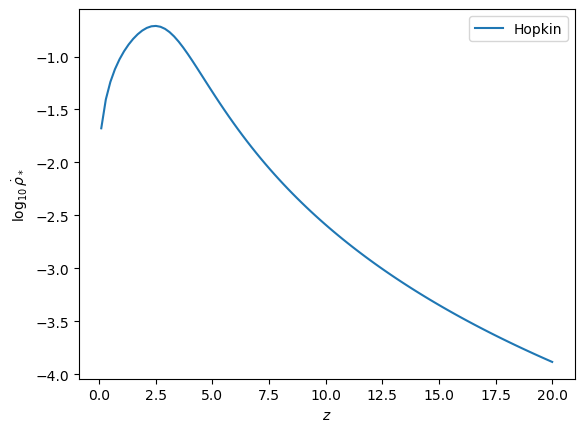

In [7]:
Hopkin_SFRD_vals = Hopkin_SFRD(z_range)
Madau_SFRD_vals = Madau(z_range)

plt.plot(z_range, np.log10(Hopkin_SFRD_vals), label = r'Hopkin')
#plt.plot(z_range, np.log10(Madau_SFRD_vals), label = r'Madau')
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}{\dot{\rho}_*}$')
plt.legend()

In [8]:
from scipy.integrate import quad

In [9]:
def n_X(E, ph_ind):
    return E ** (-ph_ind)

def I_integrand(E, ph_ind):
    return E * n_X(E, ph_ind)

E_low = 1 #keV for soft Xrays
E_high = 2 #keV for soft Xrays

def I_integral(z, E1, E2, ph_ind):
    I_integral_val, _ = quad(I_integrand, E1 * (1 + z), E2 * (1 + z), args = (ph_ind,))
    return I_integral_val

def K_X(z, ph_ind):
    return I_integral(z, E_low, E_high, ph_ind) / I_integral(0, 0.5, 8, ph_ind)

In [10]:
ph_ind = np.linspace(1, 3) #Taking photon index range

K_X_arr = np.zeros((len(z_range), len(ph_ind)))

for i in range(len(z_range)):
    for j in range(len(ph_ind)):
        K_X_arr[i][j] = K_X(z_range[i], ph_ind[j])

In [11]:
from utils import Harikane, New_SFR

In [12]:
mean_cx = np.linspace(2.6 * 10 ** (39), 3.7 * 10 ** (39)) #erg s^-1 / M yr^-1, Dijkstra (2012)

Ncx = len(mean_cx)
Nz, NGamma = K_X_arr.shape

L_X_arr = np.zeros((Ncx, Nz, NGamma))

for i, cx in enumerate(mean_cx):
    L_X_arr[i] = cx * K_X_arr

S_integrand = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Hopkin_SFRD(z_range))[:, None] * L_X_arr
S_integrand2 = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Madau(z_range))[:, None] * L_X_arr
S_integrand3 = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Harikane(z_range))[:, None] * L_X_arr
S_integrand4 = ((1 / ((1 + z_range) ** 2 * E(z_range))) * New_SFR(z_range))[:, None] * L_X_arr

In [13]:
np.where(np.abs(2 - ph_ind) == np.min(np.abs(2 - ph_ind)))

(array([25]),)

In [14]:
j = 25 #photon_index = 2

c_H_0 = (3 * 10 ** 5) / (h_new * 100)

dS_dz = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz2 = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand2[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz3 = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand3[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz4 = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand4[:,:,j] / (3.086 * 10 ** (24)) ** 2

Text(1.5, 1.3, '$\\Gamma\\approx2$')

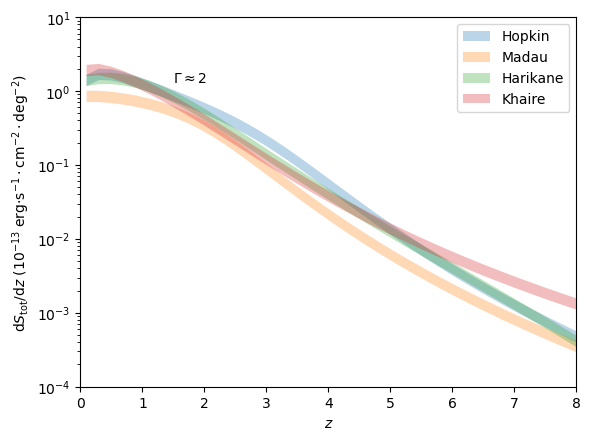

In [15]:
dSdz_min = dS_dz[0]   # shape (NΓ,)
dSdz_max = dS_dz[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz_min / (10 ** (-13)),
    dSdz_max / (10 ** (-13)),
    alpha=0.3,
    label=r'Hopkin'
)

dSdz2_min = dS_dz2[0]   # shape (NΓ,)
dSdz2_max = dS_dz2[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz2_min / (10 ** (-13)),
    dSdz2_max / (10 ** (-13)),
    alpha=0.3,
    label=r'Madau'
)

dSdz3_min = dS_dz3[0]   # shape (NΓ,)
dSdz3_max = dS_dz3[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz3_min / (10 ** (-13)),
    dSdz3_max / (10 ** (-13)),
    alpha=0.3,
    label=r'Harikane'
)

dSdz4_min = dS_dz4[0]   # shape (NΓ,)
dSdz4_max = dS_dz4[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz4_min / (10 ** (-13)),
    dSdz4_max / (10 ** (-13)),
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(z_range, dS_dz[-1] / (10 ** (-13)), label = r'Hopkin', color = r'blue')
#plt.plot(z_range, dS_dz[0] / (10 ** (-13)), label = r'Hopkin', color = r'blue')
#plt.plot(z_range, dS_dz2 / (10 ** (-13)), label = r'Madau')
#plt.plot(z_range, dS_dz3 / (10 ** (-13)), label = r'Harikane')
#plt.plot(z_range, dS_dz4 / (10 ** (-13)), label = r'Khaire')
plt.xlim(0, 8)
plt.ylim(0.0001, 10)
plt.yscale('log')
plt.ylabel(r'$\text{d}S_\text{tot}/\text{d}z$ ($10^{-13}$ erg$\cdot$s$^{-1}\cdot$cm$^{-2}\cdot$deg$^{-2}$)')
plt.xlabel(r'$z$')
plt.legend()
plt.text(1.5, 1.3, r'$\Gamma\approx2$')

In [16]:
S_integral = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral2 = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand2, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral3 = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand3, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral4 = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand4, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2

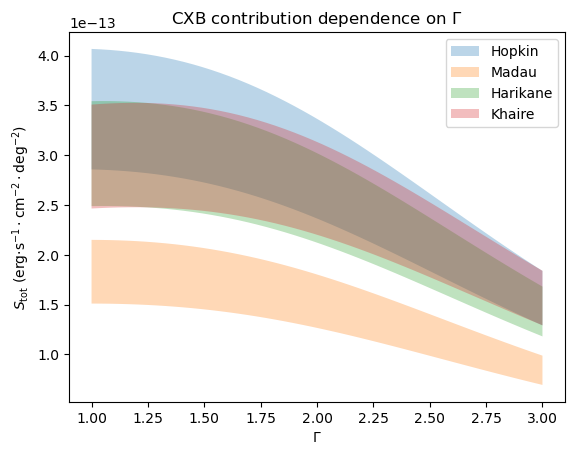

In [17]:
S_int_min = S_integral[0]
S_int_max = S_integral[-1]
plt.fill_between(
    ph_ind,
    S_int_min,
    S_int_max,
    alpha=0.3,
    label=r'Hopkin'
)

S_int_min2 = S_integral2[0]
S_int_max2 = S_integral2[-1]
plt.fill_between(
    ph_ind,
    S_int_min2,
    S_int_max2,
    alpha=0.3,
    label=r'Madau'
)

S_int_min3 = S_integral3[0]
S_int_max3 = S_integral3[-1]
plt.fill_between(
    ph_ind,
    S_int_min3,
    S_int_max3,
    alpha=0.3,
    label=r'Harikane'
)

S_int_min4 = S_integral4[0]
S_int_max4 = S_integral4[-1]
plt.fill_between(
    ph_ind,
    S_int_min4,
    S_int_max4,
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(ph_ind, S_integral, label = r'Hopkin')
#plt.plot(ph_ind, S_integral2, label = r'Madau')
#plt.plot(ph_ind, S_integral3, label = r'Harikane')
#plt.plot(ph_ind, S_integral4, label = r'Khaire')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'$S_\text{tot}$ (erg$\cdot$s$^{-1}\cdot$cm$^{-2}\cdot$deg$^{-2}$)')
plt.title(r'CXB contribution dependence on $\Gamma$')
plt.legend()

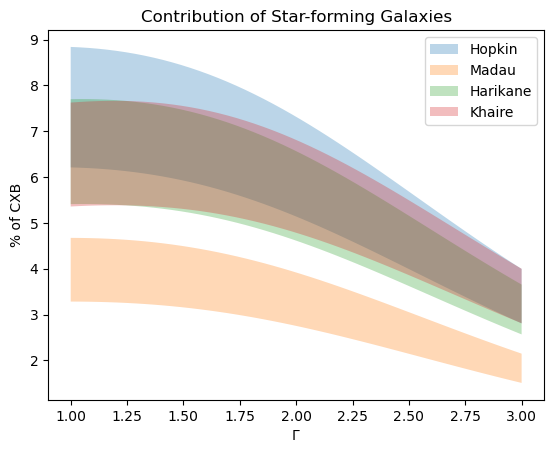

In [18]:
#percentage of total CXB

total_soft_S = 4.6* 10 ** (-12) #erg s^-1 cm^-2 deg^-2

percentage_S = S_integral / total_soft_S * 100
percentage_S2 = S_integral2 / total_soft_S * 100
percentage_S3 = S_integral3 / total_soft_S * 100
percentage_S4 = S_integral4 / total_soft_S * 100

percentage_S_min = percentage_S[0]
percentage_S_max = percentage_S[-1]
plt.fill_between(
    ph_ind,
    percentage_S_min,
    percentage_S_max,
    alpha=0.3,
    label=r'Hopkin'
)

percentage_S_min2 = percentage_S2[0]
percentage_S_max2 = percentage_S2[-1]
plt.fill_between(
    ph_ind,
    percentage_S_min2,
    percentage_S_max2,
    alpha=0.3,
    label=r'Madau'
)

percentage_S_min3 = percentage_S3[0]
percentage_S_max3 = percentage_S3[-1]
plt.fill_between(
    ph_ind,
    percentage_S_min3,
    percentage_S_max3,
    alpha=0.3,
    label=r'Harikane'
)

percentage_S_min4 = percentage_S4[0]
percentage_S_max4 = percentage_S4[-1]
plt.fill_between(
    ph_ind,
    percentage_S_min4,
    percentage_S_max4,
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(ph_ind, percentage_S, label = r'Hopkin')
#plt.plot(ph_ind, percentage_S2, label = r'Madau')
#plt.plot(ph_ind, percentage_S3, label = r'Harikane')
#plt.plot(ph_ind, percentage_S4, label = r'Khaire')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'% of CXB')
plt.title(r'Contribution of Star-forming Galaxies')
plt.legend()

## SXB with $c_\text{X}$ spread taken into account

In [19]:
mean_cx_scat = mean_cx * np.e ** (1 / 2 * (0.4 * np.log(10)) ** 2)

L_X_arr_scat = np.zeros((Ncx, Nz, NGamma))

for i, cx in enumerate(mean_cx_scat):
    L_X_arr_scat[i] = cx * K_X_arr

S_integrand_scat = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Hopkin_SFRD(z_range))[:, None] * L_X_arr_scat
S_integrand_scat2 = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Madau(z_range))[:, None] * L_X_arr_scat
S_integrand_scat3 = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Harikane(z_range))[:, None] * L_X_arr_scat
S_integrand_scat4 = ((1 / ((1 + z_range) ** 2 * E(z_range))) * New_SFR(z_range))[:, None] * L_X_arr_scat

In [20]:
j = 25 #photon_index = 2

dS_dz_scat = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand_scat[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz_scat2 = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand_scat2[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz_scat3 = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand_scat3[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz_scat4 = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand_scat4[:,:,j] / (3.086 * 10 ** (24)) ** 2

Text(0.5, 1.0, 'Differential Flux Contribution')

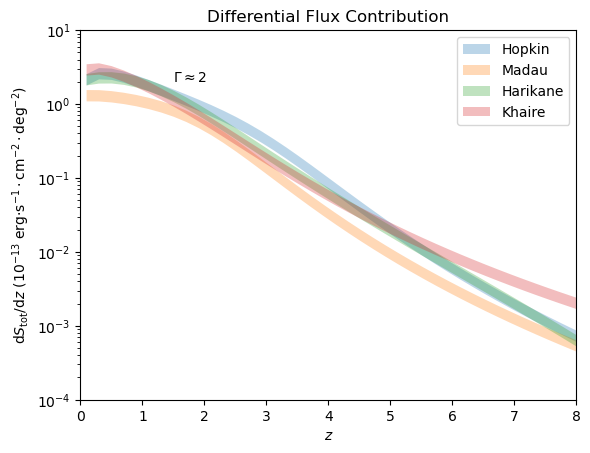

In [21]:
dSdz_scat_min = dS_dz_scat[0]   # shape (NΓ,)
dSdz_scat_max = dS_dz_scat[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz_scat_min / (10 ** (-13)),
    dSdz_scat_max / (10 ** (-13)),
    alpha=0.3,
    label=r'Hopkin'
)

dSdz_scat_min2 = dS_dz_scat2[0]   # shape (NΓ,)
dSdz_scat_max2 = dS_dz_scat2[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz_scat_min2 / (10 ** (-13)),
    dSdz_scat_max2 / (10 ** (-13)),
    alpha=0.3,
    label=r'Madau'
)

dSdz_scat_min3 = dS_dz_scat3[0]   # shape (NΓ,)
dSdz_scat_max3 = dS_dz_scat3[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz_scat_min3 / (10 ** (-13)),
    dSdz_scat_max3 / (10 ** (-13)),
    alpha=0.3,
    label=r'Harikane'
)

dSdz_scat_min4 = dS_dz_scat4[0]   # shape (NΓ,)
dSdz_scat_max4 = dS_dz_scat4[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dSdz_scat_min4 / (10 ** (-13)),
    dSdz_scat_max4 / (10 ** (-13)),
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(z_range, dS_dz_scat / (10 ** (-13)), label = r'Hopkin')
#plt.plot(z_range, dS_dz_scat2 / (10 ** (-13)), label = r'Madau')
#plt.plot(z_range, dS_dz_scat3 / (10 ** (-13)), label = r'Harikane')
#plt.plot(z_range, dS_dz_scat4 / (10 ** (-13)), label = r'Khaire')
plt.xlim(0, 8)
plt.ylim(10**(-4), 10)
plt.yscale('log')
plt.ylabel(r'$\text{d}S_\text{tot}/\text{d}z$ ($10^{-13}$ erg$\cdot$s$^{-1}\cdot$cm$^{-2}\cdot$deg$^{-2}$)')
plt.xlabel(r'$z$')
plt.legend()
plt.text(1.5, 2, r'$\Gamma\approx2$')
plt.title(r'Differential Flux Contribution')

In [22]:
S_integral_scat = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand_scat, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral_scat2 = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand_scat2, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral_scat3 = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand_scat3, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral_scat4 = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand_scat4, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2

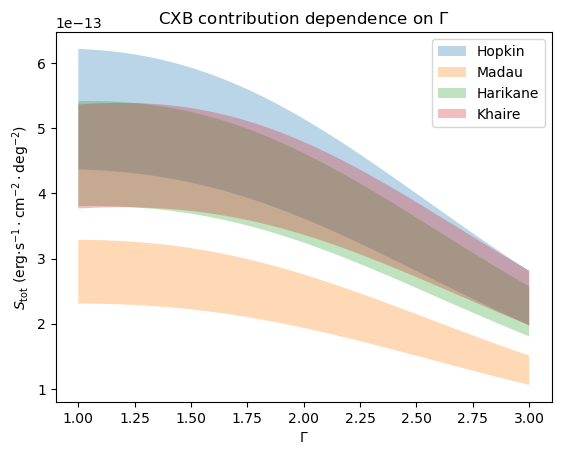

In [23]:
S_integral_scat_min = S_integral_scat[0]
S_integral_scat_max = S_integral_scat[-1]
plt.fill_between(
    ph_ind,
    S_integral_scat_min,
    S_integral_scat_max,
    alpha=0.3,
    label=r'Hopkin'
)

S_integral_scat_mi2 = S_integral_scat2[0]
S_integral_scat_ma2 = S_integral_scat2[-1]
plt.fill_between(
    ph_ind,
    S_integral_scat_mi2,
    S_integral_scat_ma2,
    alpha=0.3,
    label=r'Madau'
)

S_integral_scat_min3 = S_integral_scat3[0]
S_integral_scat_max3 = S_integral_scat3[-1]
plt.fill_between(
    ph_ind,
    S_integral_scat_min3,
    S_integral_scat_max3,
    alpha=0.3,
    label=r'Harikane'
)

S_integral_scat_min4 = S_integral_scat4[0]
S_integral_scat_max4 = S_integral_scat4[-1]
plt.fill_between(
    ph_ind,
    S_integral_scat_min4,
    S_integral_scat_max4,
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(ph_ind, S_integral_scat, label = r'Hopkin')
#plt.plot(ph_ind, S_integral_scat2, label = r'Madau')
#plt.plot(ph_ind, S_integral_scat3, label = r'Harikane')
#plt.plot(ph_ind, S_integral_scat4, label =  r'Khaire')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'$S_\text{tot}$ (erg$\cdot$s$^{-1}\cdot$cm$^{-2}\cdot$deg$^{-2}$)')
plt.title(r'CXB contribution dependence on $\Gamma$')
plt.legend()

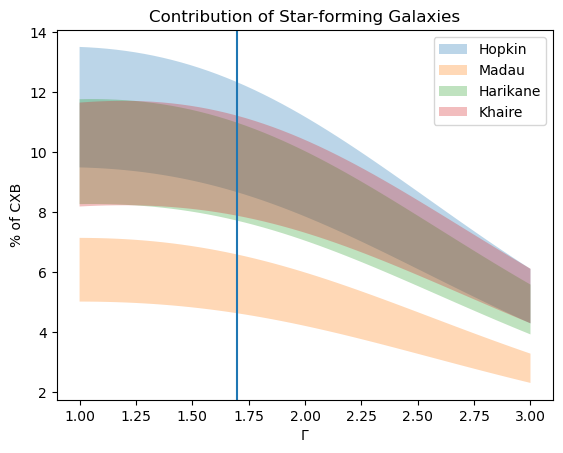

In [24]:
#percentage of total CXB

percentage_S_scat = S_integral_scat / total_soft_S * 100
percentage_S_scat2 = S_integral_scat2 / total_soft_S * 100
percentage_S_scat3 = S_integral_scat3 / total_soft_S * 100
percentage_S_scat4 = S_integral_scat4 / total_soft_S * 100

percentage_S_scat_min = percentage_S_scat[0]
percentage_S_scat_max = percentage_S_scat[-1]
plt.fill_between(
    ph_ind,
    percentage_S_scat_min,
    percentage_S_scat_max,
    alpha=0.3,
    label=r'Hopkin'
)

percentage_S_scat_min2 = percentage_S_scat2[0]
percentage_S_scat_max2 = percentage_S_scat2[-1]
plt.fill_between(
    ph_ind,
    percentage_S_scat_min2,
    percentage_S_scat_max2,
    alpha=0.3,
    label=r'Madau'
)

percentage_S_scat_min3 = percentage_S_scat3[0]
percentage_S_scat_max3 = percentage_S_scat3[-1]
plt.fill_between(
    ph_ind,
    percentage_S_scat_min3,
    percentage_S_scat_max3,
    alpha=0.3,
    label=r'Harikane'
)

percentage_S_scat_min4 = percentage_S_scat4[0]
percentage_S_scat_max4 = percentage_S_scat4[-1]
plt.fill_between(
    ph_ind,
    percentage_S_scat_min4,
    percentage_S_scat_max4,
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(ph_ind, percentage_S_scat, label = r'Hopkin')
#plt.plot(ph_ind, percentage_S_scat2, label = r'Madau')
#plt.plot(ph_ind, percentage_S_scat3, label = r'Harikane')
#plt.plot(ph_ind, percentage_S_scat4, label = r'Khaire')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'% of CXB')
plt.title(r'Contribution of Star-forming Galaxies')
plt.legend()
plt.axvline(1.7)

In [50]:
target = 1.7
idx = np.abs(ph_ind - target).argmin()

madau_value = percentage_S_scat_min2[idx]
hopkins_value = percentage_S_scat_max[idx]

print(f"Gamma ≈ {ph_ind[idx]:.3f}")
print(f"Madau (lower band) ≈ {madau_value:.2f}%")
print(f"Hopkins (upper band) ≈ {hopkins_value:.2f}%")

Gamma ≈ 1.694
Madau (lower band) ≈ 4.64%
Hopkins (upper band) ≈ 12.35%


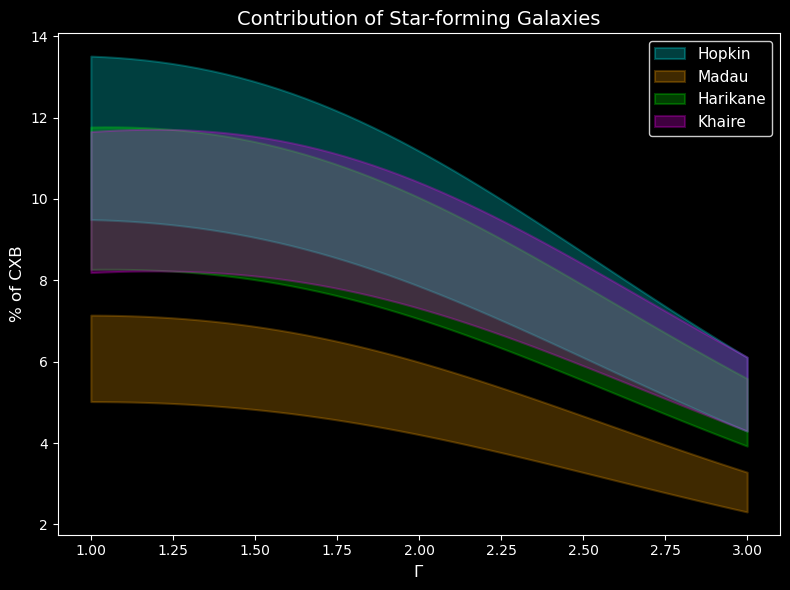

In [51]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Filled regions (use bright colors + edges) ---
ax.fill_between(
    ph_ind,
    percentage_S_scat[0],
    percentage_S_scat[-1],
    color='#00FFFF', alpha=0.25,
    edgecolor='#00FFFF', linewidth=1.5,
    label=r'Hopkin'
)

ax.fill_between(
    ph_ind,
    percentage_S_scat2[0],
    percentage_S_scat2[-1],
    color='#FFA500', alpha=0.25,
    edgecolor='#FFA500', linewidth=1.5,
    label=r'Madau'
)

ax.fill_between(
    ph_ind,
    percentage_S_scat3[0],
    percentage_S_scat3[-1],
    color='#00FF00', alpha=0.25,
    edgecolor='#00FF00', linewidth=1.5,
    label=r'Harikane'
)

ax.fill_between(
    ph_ind,
    percentage_S_scat4[0],
    percentage_S_scat4[-1],
    color='#FF00FF', alpha=0.25,
    edgecolor='#FF00FF', linewidth=1.5,
    label=r'Khaire'
)

# --- Labels & title ---
ax.set_xlabel(r'$\Gamma$', fontsize=12, color='white')
ax.set_ylabel(r'% of CXB', fontsize=12, color='white')
ax.set_title(r'Contribution of Star-forming Galaxies', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

In [26]:
np.round((S_integral / S_integral_scat)[0][0], 2) #Extra factor with spread taken into account

np.float64(0.65)

## HXB with $c_\text{X}$ spread taken into account

In [27]:
E_low_H = 2
E_high_H = 8

def K_X_hard(z, ph_ind):
    return I_integral(z, E_low_H, E_high_H, ph_ind) / I_integral(0, 0.5, 8, ph_ind)

In [28]:
K_X_arr_H = np.zeros((len(z_range), len(ph_ind)))

for i in range(len(z_range)):
    for j in range(len(ph_ind)):
        K_X_arr_H[i][j] = K_X_hard(z_range[i], ph_ind[j])

In [29]:
L_X_arr_H = np.zeros((Ncx, Nz, NGamma))

for i, cx in enumerate(mean_cx_scat):
    L_X_arr_H[i] = cx * K_X_arr_H

S_integrand_H = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Hopkin_SFRD(z_range))[:, None] * L_X_arr_H
S_integrand2_H = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Madau(z_range))[:, None] * L_X_arr_H
S_integrand3_H = ((1 / ((1 + z_range) ** 2 * E(z_range))) * Harikane(z_range))[:, None] * L_X_arr_H
S_integrand4_H = ((1 / ((1 + z_range) ** 2 * E(z_range))) * New_SFR(z_range))[:, None] * L_X_arr_H

In [30]:
dS_dz_H = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand_H[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz2_H = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand2_H[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz3_H = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand3_H[:,:,j] / (3.086 * 10 ** (24)) ** 2
dS_dz4_H = delta_Omega / (4 * np.pi) * c_H_0 * S_integrand4_H[:,:,j] / (3.086 * 10 ** (24)) ** 2

Text(0.5, 1.0, 'Differential Flux Contribution')

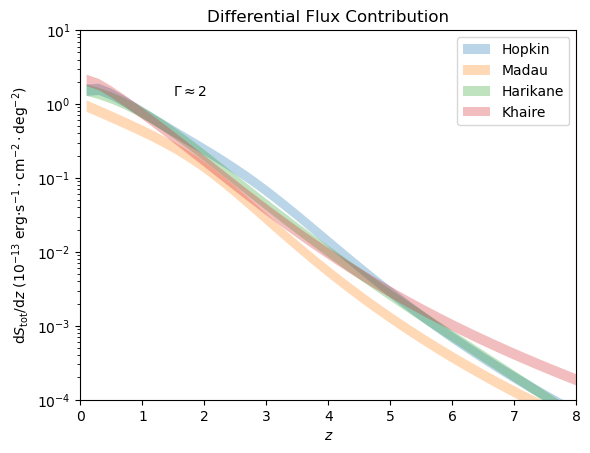

In [31]:
dS_dz_H_min = dS_dz_H[0]   # shape (NΓ,)
dS_dz_H_max = dS_dz_H[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dS_dz_H_min / (10 ** (-13)),
    dS_dz_H_max / (10 ** (-13)),
    alpha=0.3,
    label=r'Hopkin'
)

dS_dz_H_min2 = dS_dz2_H[0]   # shape (NΓ,)
dS_dz_H_max2 = dS_dz2_H[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dS_dz_H_min2 / (10 ** (-13)),
    dS_dz_H_max2 / (10 ** (-13)),
    alpha=0.3,
    label=r'Madau'
)

dS_dz_H_min3 = dS_dz3_H[0]   # shape (NΓ,)
dS_dz_H_max3 = dS_dz3_H[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dS_dz_H_min3 / (10 ** (-13)),
    dS_dz_H_max3 / (10 ** (-13)),
    alpha=0.3,
    label=r'Harikane'
)

dS_dz_H_min4 = dS_dz4_H[0]   # shape (NΓ,)
dS_dz_H_max4 = dS_dz4_H[-1]   # shape (NΓ,)
plt.fill_between(
    z_range,
    dS_dz_H_min4 / (10 ** (-13)),
    dS_dz_H_max4 / (10 ** (-13)),
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(z_range, dS_dz_H / (10 ** (-13)), label = r'Hopkin')
#plt.plot(z_range, dS_dz2_H / (10 ** (-13)), label = r'Madau')
#plt.plot(z_range, dS_dz3_H / (10 ** (-13)), label = r'Harikane')
#plt.plot(z_range, dS_dz4_H / (10 ** (-13)), label = r'Khaire')
plt.xlim(0, 8)
plt.ylim(10**(-4), 10)
plt.yscale('log')
plt.ylabel(r'$\text{d}S_\text{tot}/\text{d}z$ ($10^{-13}$ erg$\cdot$s$^{-1}\cdot$cm$^{-2}\cdot$deg$^{-2}$)')
plt.xlabel(r'$z$')
plt.legend()
plt.text(1.5, 1.3, r'$\Gamma\approx2$')
plt.title(r'Differential Flux Contribution')

In [32]:
S_integral_H = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand_H, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral2_H = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand2_H, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral3_H = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand3_H, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2
S_integral4_H = delta_Omega / (4 * np.pi) * c_H_0 * np.trapezoid(S_integrand4_H, x = z_range, axis = 1) / (3.086 * 10 ** (24)) ** 2 #in erg s^-1 cm^-2 deg^-2

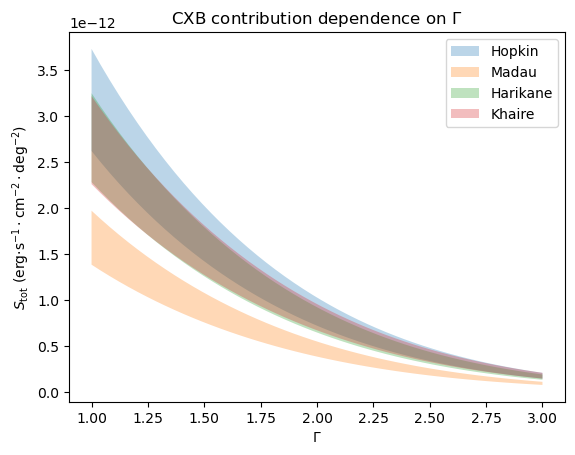

In [53]:
S_integral_H_min = S_integral_H[0]   
S_integral_H_max = S_integral_H[-1]   
plt.fill_between(
    ph_ind,
    S_integral_H_min,
    S_integral_H_max,
    alpha=0.3,
    label=r'Hopkin'
)

S_integral_H_min2 = S_integral2_H[0]   
S_integral_H_max2 = S_integral2_H[-1]   
plt.fill_between(
    ph_ind,
    S_integral_H_min2,
    S_integral_H_max2,
    alpha=0.3,
    label=r'Madau'
)

S_integral_H_min3 = S_integral3_H[0]   
S_integral_H_max3 = S_integral3_H[-1]   
plt.fill_between(
    ph_ind,
    S_integral_H_min3,
    S_integral_H_max3,
    alpha=0.3,
    label=r'Harikane'
)

S_integral_H_min4 = S_integral4_H[0]   
S_integral_H_max4 = S_integral4_H[-1]   
plt.fill_between(
    ph_ind,
    S_integral_H_min4,
    S_integral_H_max4,
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(ph_ind, S_integral_H, label = r'Hopkin')
#plt.plot(ph_ind, S_integral2_H, label = r'Madau')
#plt.plot(ph_ind, S_integral3_H, label = r'Harikane')
#plt.plot(ph_ind, S_integral4_H, label =  r'Khaire')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'$S_\text{tot}$ (erg$\cdot$s$^{-1}\cdot$cm$^{-2}\cdot$deg$^{-2}$)')
plt.title(r'CXB contribution dependence on $\Gamma$')
plt.legend()

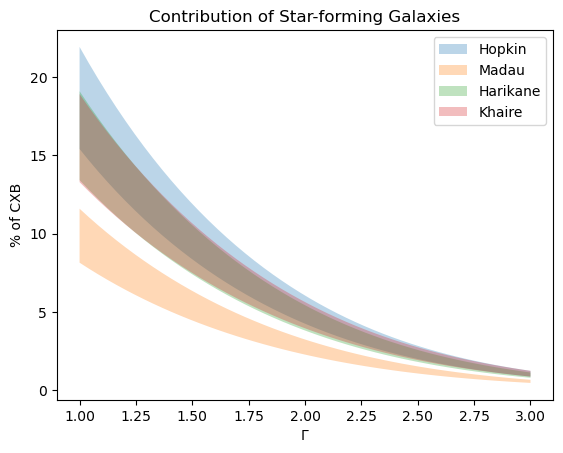

In [34]:
#percentage of total CXB

total_hard_S = 1.7 * 10 ** (-11) #erg s^{-1} cm^{-2} deg^{-2}

percentage_S_H = S_integral_H / total_hard_S * 100
percentage_S2_H = S_integral2_H / total_hard_S * 100
percentage_S3_H = S_integral3_H / total_hard_S * 100
percentage_S4_H = S_integral4_H / total_hard_S * 100

percentage_S_H_min = percentage_S_H[0]   
percentage_S_H_max = percentage_S_H[-1]   
plt.fill_between(
    ph_ind,
    percentage_S_H_min,
    percentage_S_H_max,
    alpha=0.3,
    label=r'Hopkin'
)

percentage_S_H_min2 = percentage_S2_H[0]   
percentage_S_H_max2 = percentage_S2_H[-1]  
plt.fill_between(
    ph_ind,
    percentage_S_H_min2,
    percentage_S_H_max2,
    alpha=0.3,
    label=r'Madau'
)

percentage_S_H_min3 = percentage_S3_H[0]   
percentage_S_H_max3 = percentage_S3_H[-1]   
plt.fill_between(
    ph_ind,
    percentage_S_H_min3,
    percentage_S_H_max3,
    alpha=0.3,
    label=r'Harikane'
)

percentage_S_H_min4 = percentage_S4_H[0]   
percentage_S_H_max4 = percentage_S4_H[-1]   
plt.fill_between(
    ph_ind,
    percentage_S_H_min4,
    percentage_S_H_max4,
    alpha=0.3,
    label=r'Khaire'
)

#plt.plot(ph_ind, percentage_S_H, label = r'Hopkin')
#plt.plot(ph_ind, percentage_S2_H, label = r'Madau')
#plt.plot(ph_ind, percentage_S3_H, label = r'Harikane')
#plt.plot(ph_ind, percentage_S4_H, label = r'Khaire')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'% of CXB')
plt.title(r'Contribution of Star-forming Galaxies')
plt.legend()

In [52]:
target = 1.7
idx = np.abs(ph_ind - target).argmin()

madau_value_H = percentage_S_H_min2[idx]
hopkins_value_H = percentage_S_H_max[idx]

print(f"Gamma ≈ {ph_ind[idx]:.3f}")
print(f"Madau (lower band, hard) ≈ {madau_value_H:.2f}%")
print(f"Hopkins (upper band, hard) ≈ {hopkins_value_H:.2f}%")

Gamma ≈ 1.694
Madau (lower band, hard) ≈ 3.47%
Hopkins (upper band, hard) ≈ 9.24%


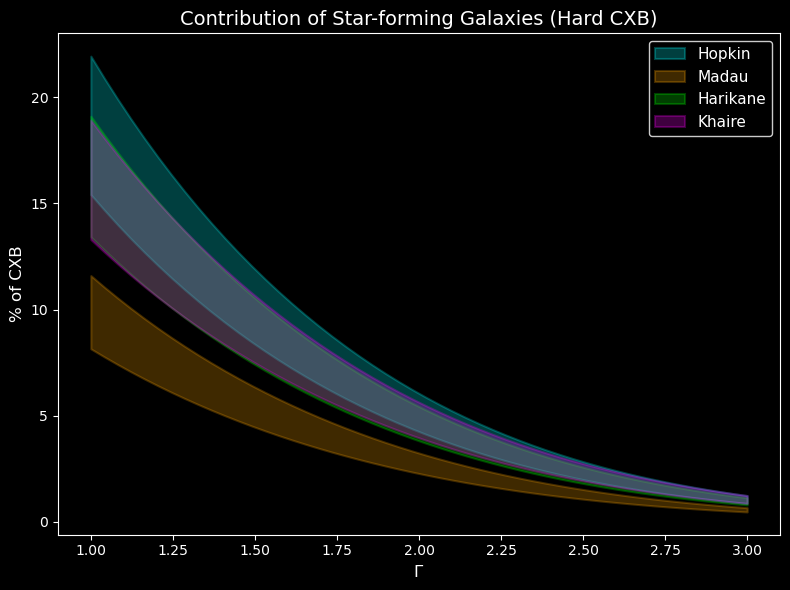

In [35]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Filled regions ---
ax.fill_between(
    ph_ind,
    percentage_S_H[0],
    percentage_S_H[-1],
    color='#00FFFF', alpha=0.25,
    edgecolor='#00FFFF', linewidth=1.5,
    label=r'Hopkin'
)

ax.fill_between(
    ph_ind,
    percentage_S2_H[0],
    percentage_S2_H[-1],
    color='#FFA500', alpha=0.25,
    edgecolor='#FFA500', linewidth=1.5,
    label=r'Madau'
)

ax.fill_between(
    ph_ind,
    percentage_S3_H[0],
    percentage_S3_H[-1],
    color='#00FF00', alpha=0.25,
    edgecolor='#00FF00', linewidth=1.5,
    label=r'Harikane'
)

ax.fill_between(
    ph_ind,
    percentage_S4_H[0],
    percentage_S4_H[-1],
    color='#FF00FF', alpha=0.25,
    edgecolor='#FF00FF', linewidth=1.5,
    label=r'Khaire'
)

# --- Labels & title ---
ax.set_xlabel(r'$\Gamma$', fontsize=12, color='white')
ax.set_ylabel(r'% of CXB', fontsize=12, color='white')
ax.set_title(r'Contribution of Star-forming Galaxies (Hard CXB)', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

# X-Ray faint Galaxies Contribution to SXB

In [36]:
Gamma = 2.0
s_max = 2.4 * 10 ** (-18) #erg s^{-1} cm^{-2}
SFR_min = 10 ** (-3) #SM yr^{-1}
SFR_max = 10 ** 5 #SM/yr

psi_st_0 = 9.2 #SM/yr
phi_st_0 = 1.6 * 10 ** (-4) #cMpc^{-3}
alpha_0 = -1.51

## Varying $\psi^*(z)$ keeping $\Phi^*$ fixed:

Text(0.5, 0, '$z$')

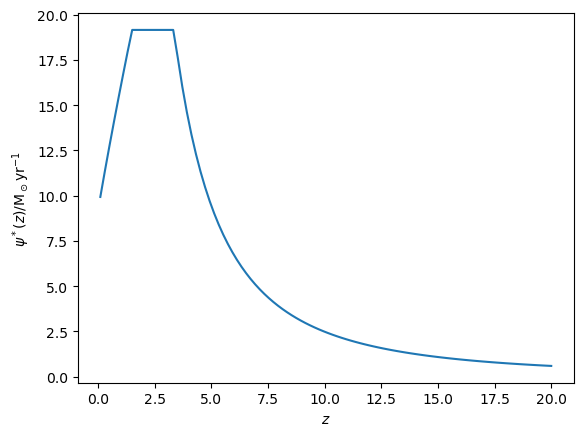

In [37]:
def Psi_st(z):
    z_1 = 1.5
    z_2 = 3.35
    if z < z_1:
        Psi_st_arr = 9.2 * (1 + z) ** 0.8
    elif z_1 <= z < z_2:
        Psi_st_arr = 9.2 * (1 + z_1) ** 0.8
    else:
        Psi_st_arr = 9.2 * (1 + z_1) ** 0.8 * ((1 + z_2) / (1 + z)) ** 2.2
    return Psi_st_arr

Psi_st_vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    Psi_st_vals[i] = Psi_st(z_range[i])

plt.plot(z_range, Psi_st_vals)
plt.ylabel(r'$\psi^*(z)/$M$_\odot$yr$^{-1}$')
plt.xlabel(r'$z$')

In [38]:
def alpha(z):
    def g(z):
        return (2 / np.pi) * np.arctan(z)
    return alpha_0 - 0.23 * g(z)

def n(Psi, z):
    return (phi_st_0 / Psi_st(z)) * (Psi / Psi_st(z)) ** alpha(z) * np.e ** (-Psi / Psi_st(z))

def Psi_var_SFRD(Psi_min, Psi_max, z):
    def integrand(Psi, z):
        return Psi * n(Psi, z)
    val, _ = quad(integrand, 0, np.inf, args = (z,))
    return val

In [39]:
Psi_var_SFRD_vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    Psi_var_SFRD_vals[i] = Psi_var_SFRD(SFR_min, SFR_max, z_range[i])

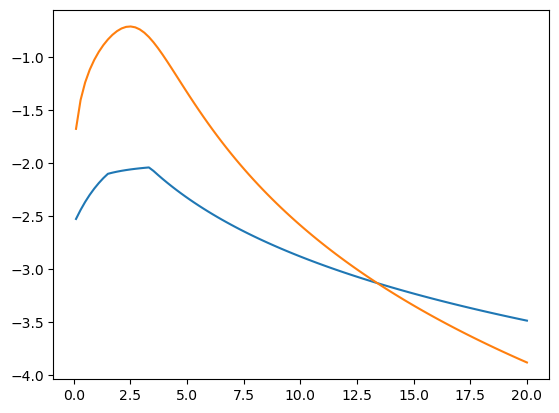

In [40]:
plt.plot(z_range, np.log10(Psi_var_SFRD_vals))
plt.plot(z_range, np.log10(Hopkin_SFRD_vals))

### Varying $\Phi^*(z)$ keeping $\psi^*$ fixed:

In [41]:
from scipy.special import gamma

In [42]:
def Phi_star(z):
    return Hopkin_SFRD(z) / (psi_st_0 * gamma(alpha(z) + 2))

In [43]:
def n(Psi, z):
    return (Phi_star(z) / psi_st_0) * (Psi / psi_st_0) ** alpha(z) * np.e ** (-Psi / psi_st_0)

def Phi_var_SFRD(Psi_min, Psi_max, z):
    def integrand(Psi, z):
        return Psi * n(Psi, z)
    val, _ = quad(integrand, 0, np.inf, args = (z,))
    return val

In [44]:
Phi_var_SFRD_vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    Phi_var_SFRD_vals[i] = Phi_var_SFRD(SFR_min, SFR_max, z_range[i])

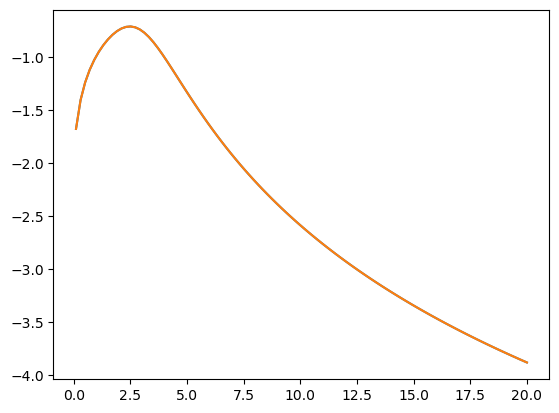

In [45]:
plt.plot(z_range, np.log10(Phi_var_SFRD_vals))
plt.plot(z_range, np.log10(Hopkin_SFRD_vals))

In [46]:
sigma_scat = 0.4

def P_logLX(psi, logLX):
    mean_LX = mean_cx * psi
    return 1 / (np.sqrt(2 * np.pi) * sigma_scat) * np.e ** (-(logLX - np.log10(mean_LX)) ** 2 / (2 * sigma_scat ** 2))

In [47]:
def SFRden(logLX, psi_min, psi_max, z):
    psi_grid = np.linspace(SFR_min, SFR_max)
    integrand = np.zeros((Npsi, len(mean_cx)))
    for i, psi in enumerate(psi_grid):
        for j, cX in enumerate(mean_cx):
            integrand[i, j] = n(psi, z) * P_logLX_given_psi(logLX, psi, cX)
    result = np.trapezoid(integrand, x=psi_grid, axis = 0)

In [48]:
def d_L_array(z_arr):
    """
    Luminosity distance d_L(z) for an array of redshifts.

    Parameters
    ----------
    z_arr : array_like
        Redshift array (must be sorted ascending)

    Returns
    -------
    dL : ndarray
        Luminosity distance in cm, same shape as z_arr
    """

    # Integral of 1/E(z) from 0 to z
    integrand = 1.0 / E(z_arr)
    chi = cumulative_trapezoid(integrand, x=z_arr, initial=0.0)

    # Convert to luminosity distance
    Mpc_to_cm = 3.085677581e24
    dL = (1.0 + z_arr) * c_H_0 * chi * Mpc_to_cm

    return dL

def SX(z, psi_min, psi_max, s_max, ph_ind):
    prefactor = delta_Omega / (4 * np.pi) * c_H_0
    def integrand1(z):
        return 1 / ((1 + z) ** 2 * E(z))
    integrand1_vals = np.zeros_like(z)
    for i in range(len(z)):
        integrand1_vals[i] = integrand1(z[i])
    integration1 = np.trapezoid(integrand1_vals, x=z)
    L_X_max = 4 * np.pi * d_L_array(z) ** 2 * s_max / K_X(z, ph_ind)
    LX_grid = np.linspace(0, L_X_max)
    log_LX_grid = np.log10(LX_grid)
    def integrand2(logLX):
        return SFRden(logLX, psi_min, psi_max, z) * 10 ** (logLX) * K_X(z, ph_ind)
    integrand2_vals = np.zeros_like(log_LX_grid)
    for j in range(len(log_LX_grid)):
        integrand2_vals[j] = integrand2(log_LX_grid[j])
    integration2 = np.trapezoid(integrand2_vals, x=log_LX_grid)
    return prefactor * integration1 * integration2

In [49]:
SX = SX(z_range, SFR_min, SFR_max, s_max, 2)

NameError: name 'cumulative_trapezoid' is not defined